# PrimeTrade.ai Data Science Assignment

## Analyzing the Relationship Between Bitcoin Market Sentiment and Trader Performance

### Objective
This project analyzes the relationship between Bitcoin market sentiment (Fear & Greed Index) and Hyperliquid trader performance. The analysis explores how market sentiment influences trading activity, profitability, win rate, and trading behavior.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
trades = pd.read_csv("historical_data.csv")
fear = pd.read_csv("fear_greed_index.csv")

In [4]:
print("Trader Data Columns:")
print(trades.columns)


Trader Data Columns:
Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='object')


In [5]:
print("\nFear & Greed Columns:")
print(fear.columns)


Fear & Greed Columns:
Index(['timestamp', 'value', 'classification', 'date'], dtype='object')


In [6]:
print("Missing values in Trader Data:")
print(trades.isnull().sum())

print("\nMissing values in Fear & Greed Data:")
print(fear.isnull().sum())

Missing values in Trader Data:
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

Missing values in Fear & Greed Data:
timestamp         0
value             0
classification    0
date              0
dtype: int64


In [7]:
trades.drop_duplicates(inplace=True)
fear.drop_duplicates(inplace=True)

print("Trader Data Shape:", trades.shape)
print("Fear & Greed Shape:", fear.shape)


Trader Data Shape: (211224, 16)
Fear & Greed Shape: (2644, 4)


In [9]:
trades["Date"] = pd.to_datetime(
    trades["Timestamp IST"],
    format="%d-%m-%Y %H:%M"
).dt.date

fear["Date"] = pd.to_datetime(fear["date"]).dt.date

In [10]:
trades[["Timestamp IST", "Date"]].head()

,Timestamp IST,Date
0,02-12-2024 22:50,2024-12-02
1,02-12-2024 22:50,2024-12-02
2,02-12-2024 22:50,2024-12-02
3,02-12-2024 22:50,2024-12-02
4,02-12-2024 22:50,2024-12-02


In [11]:
merged_data = pd.merge(
    trades,
    fear[["Date", "classification", "value"]],
    on="Date",
    how="left"
)

print("Merged Data Shape:", merged_data.shape)

Merged Data Shape: (211224, 19)


In [12]:
merged_data[["Date", "classification", "value"]].head(10)

,Date,classification,value
0,2024-12-02,Extreme Greed,80.0
1,2024-12-02,Extreme Greed,80.0
2,2024-12-02,Extreme Greed,80.0
3,2024-12-02,Extreme Greed,80.0
4,2024-12-02,Extreme Greed,80.0
5,2024-12-02,Extreme Greed,80.0
6,2024-12-02,Extreme Greed,80.0
7,2024-12-02,Extreme Greed,80.0
8,2024-12-02,Extreme Greed,80.0
9,2024-12-02,Extreme Greed,80.0


In [13]:
print("Total Trades:", len(merged_data))
print("Total Columns:", merged_data.shape[1])

Total Trades: 211224
Total Columns: 19


In [14]:
merged_data["classification"].value_counts()

,count
classification,
Fear,61837
Greed,50303
Extreme Greed,39992
Neutral,37686
Extreme Fear,21400


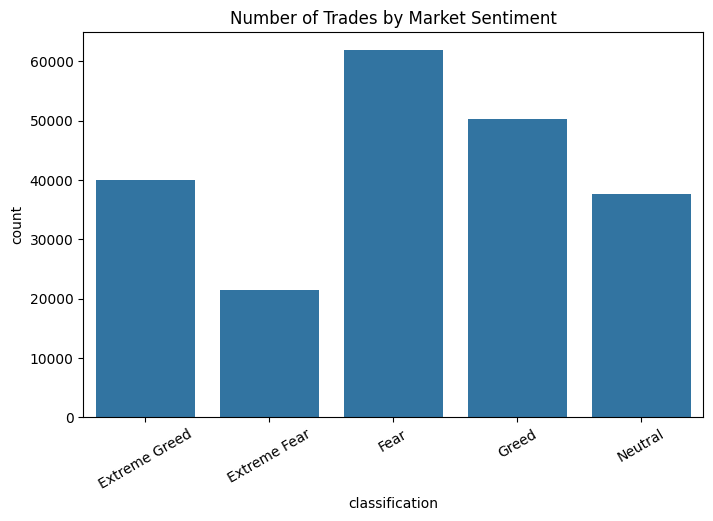

In [15]:
plt.figure(figsize=(8,5))
sns.countplot(data=merged_data, x="classification")
plt.title("Number of Trades by Market Sentiment")
plt.xticks(rotation=30)
plt.show()


In [17]:
avg_pnl = merged_data.groupby("classification")["Closed PnL"].mean().reset_index()
print(avg_pnl)

  classification  Closed PnL
0   Extreme Fear   34.537862
1  Extreme Greed   67.892861
2           Fear   54.290400
3          Greed   42.743559
4        Neutral   34.307718


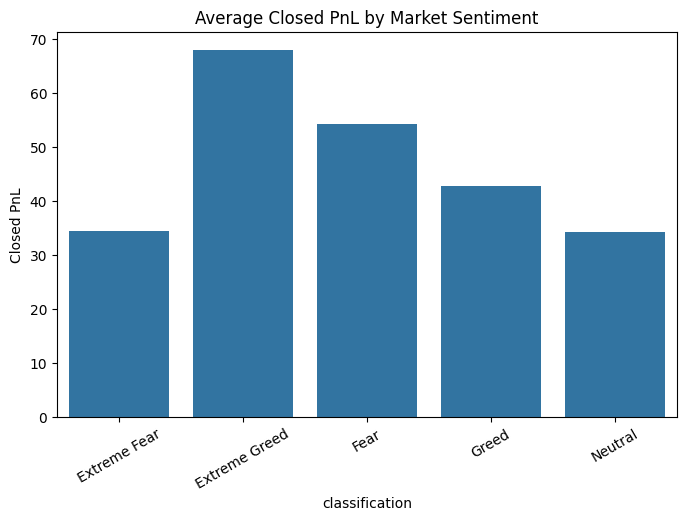

In [18]:
plt.figure(figsize=(8,5))
sns.barplot(data=avg_pnl, x="classification", y="Closed PnL")
plt.title("Average Closed PnL by Market Sentiment")
plt.xticks(rotation=30)
plt.show()

### Insight

- Extreme Greed recorded the highest average Closed PnL (~67.9).
- Fear had the second-highest average Closed PnL (~54.3).
- Extreme Fear and Neutral showed the lowest average profitability.
- This suggests traders earned more per trade during optimistic market conditions.

In [19]:
total_pnl = merged_data.groupby("classification")["Closed PnL"].sum().reset_index()
print(total_pnl)

  classification    Closed PnL
0   Extreme Fear  7.391102e+05
1  Extreme Greed  2.715171e+06
2           Fear  3.357155e+06
3          Greed  2.150129e+06
4        Neutral  1.292921e+06


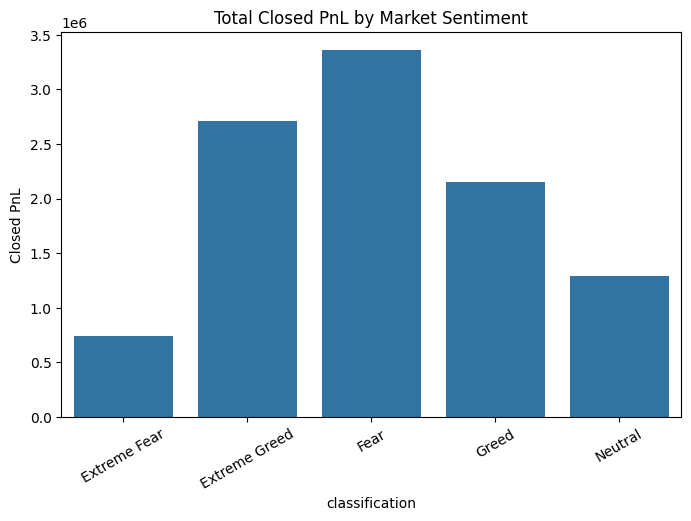

In [20]:
plt.figure(figsize=(8,5))
sns.barplot(data=total_pnl, x="classification", y="Closed PnL")
plt.title("Total Closed PnL by Market Sentiment")
plt.xticks(rotation=30)
plt.show()

### Key Insights

- Fear recorded the highest total Closed PnL (≈3.36 million).
- Extreme Greed generated the second-highest total Closed PnL (≈2.72 million).
- Greed ranked third in total profitability.
- Neutral and Extreme Fear produced comparatively lower total Closed PnL.
- The high total Closed PnL during Fear is likely influenced by the larger number of trades executed under Fear market conditions.

In [21]:
merged_data["Win"] = merged_data["Closed PnL"] > 0

win_rate = merged_data.groupby("classification")["Win"].mean() * 100

print(win_rate)

classification
Extreme Fear     37.060748
Extreme Greed    46.494299
Fear             42.076750
Greed            38.482794
Neutral          39.699093
Name: Win, dtype: float64


### Key Insights

- Extreme Greed achieved the highest win rate (46.49%).
- Fear recorded the second-highest win rate (42.08%).
- Neutral had a moderate win rate (39.70%).
- Greed achieved a win rate of 38.48%.
- Extreme Fear recorded the lowest win rate (37.06%), indicating fewer profitable trades during highly pessimistic market conditions.

In [22]:
trade_size = merged_data.groupby("classification")["Size USD"].mean().reset_index()
print(trade_size)

  classification     Size USD
0   Extreme Fear  5349.731843
1  Extreme Greed  3112.251565
2           Fear  7816.109931
3          Greed  5736.884375
4        Neutral  4782.732661


### Key Insights

- Fear had the highest average trade size (≈7816 USD).
- Greed recorded the second-highest average trade size (≈5737 USD).
- Extreme Fear and Neutral showed relatively smaller average trade sizes.
- This suggests traders committed larger amounts of capital during Fear market conditions.

In [23]:
pd.crosstab(merged_data["Side"], merged_data["classification"])

classification,Extreme Fear,Extreme Greed,Fear,Greed,Neutral
Side,,,,,
BUY,10935,17940,30270,24576,18969
SELL,10465,22052,31567,25727,18717


### Key Insights

- Buy and Sell trades were relatively balanced across all market sentiment categories.
- Fear recorded the highest number of both Buy and Sell trades.
- Extreme Fear had the lowest trading activity.
- No significant directional bias was observed between Buy and Sell positions.

In [24]:
merged_data.groupby("classification")["Fee"].mean()

,Fee
classification,
Extreme Fear,1.116291
Extreme Greed,0.675902
Fear,1.495172
Greed,1.254372
Neutral,1.044798


### Key Insights

- Fear recorded the highest average trading fee (≈1.50).
- Greed had the second-highest average trading fee (≈1.25).
- Extreme Fear and Neutral had moderate average trading fees.
- Extreme Greed recorded the lowest average trading fee (≈0.68).
- The variation in average trading fees across market sentiments is relatively small, suggesting that trading fees are influenced more by trade size and execution than by market sentiment alone.

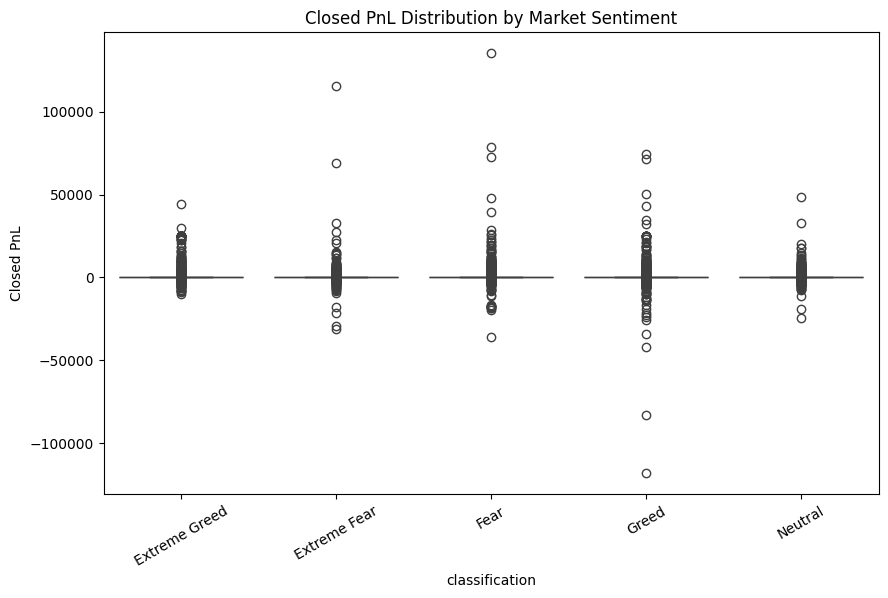

In [25]:
plt.figure(figsize=(10,6))
sns.boxplot(data=merged_data, x="classification", y="Closed PnL")
plt.title("Closed PnL Distribution by Market Sentiment")
plt.xticks(rotation=30)
plt.show()

### Key Insights

- The distribution of Closed PnL varies across different market sentiment categories.
- All sentiment categories contain both profitable and loss-making trades.
- Several extreme profit and loss outliers are visible, indicating that some trades generated exceptionally high gains or significant losses.
- Fear and Greed periods exhibit greater variability in trader outcomes compared to Neutral conditions.
- These results suggest that while market sentiment influences trading performance, individual trade outcomes remain highly variable.

## Correlation Analysis

This analysis examines the relationship between the Bitcoin Fear & Greed Index score (`value`) and traders' Closed PnL.

In [26]:
# Correlation between Fear & Greed score and Closed PnL
correlation = merged_data[["value", "Closed PnL"]].corr()

print(correlation)

               value  Closed PnL
value       1.000000    0.008121
Closed PnL  0.008121    1.000000


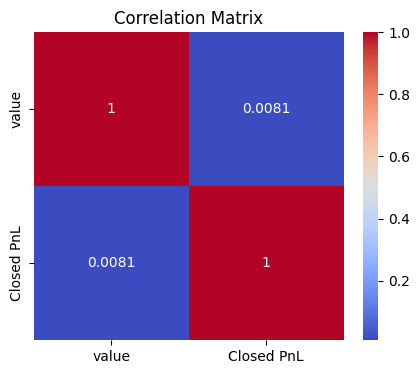

In [27]:
plt.figure(figsize=(5,4))
sns.heatmap(correlation, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

### Key Insights

- The correlation coefficient between the Fear & Greed Index score and Closed PnL is **0.0081**.
- This value is very close to **0**, indicating **almost no linear relationship** between market sentiment and the profit or loss of individual trades.
- While earlier analyses showed differences in average profit, total profit, and win rate across sentiment categories, the overall Fear & Greed score alone is not a strong predictor of individual trade profitability.
- This suggests that trader performance is influenced by multiple factors, such as trading strategy, position size, timing, and market conditions, rather than sentiment alone.

# Conclusion

This project analyzed the relationship between Bitcoin market sentiment and trader performance using the Fear & Greed Index and Hyperliquid historical trading data.

## Key Findings

- Fear market conditions recorded the highest trading activity.
- Extreme Greed achieved the highest average Closed PnL and the highest win rate.
- Fear generated the highest total Closed PnL due to increased trading activity.
- Buy and Sell trades were relatively balanced across all market sentiment categories.
- Average trading fees varied only slightly across different market conditions.
- The PnL distribution showed that both high profits and significant losses occurred under all market sentiments.

Overall, the analysis suggests that Bitcoin market sentiment influences trader behavior and profitability. Optimistic market conditions (Extreme Greed) were associated with higher average profitability, while Fear periods experienced greater trading participation and higher cumulative profits.